In [2]:
import os
os.environ["R_HOME"] = "/scratch/users/k21066795/conda/miloR/lib/R"


import sys
sys.path.append('/scratch/users/k21066795/conda/miloR')
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')

import glob
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import leidenalg
import scanpy as sc
import anndata

import seaborn as sns
import matplotlib.pyplot as plt

import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging

from utils_pheno import * 

In [3]:
file_path = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/adata/adata_NBTs_4levels.h5ad'
adata_normal = sc.read_h5ad(file_path)

patient_ids = []
for i in list(adata_normal.obs["wsi_id"]):
    if "_FPE_" in i:
        patient_id = str(i.split("_FPE_")[0])
        patient_ids.append(patient_id)
    else:
        patient_id = str(i.split("_")[1])
        patient_ids.append(patient_id)


adata_normal.obs["patient_id"] = patient_ids
adata_normal.obs["patient_id"] = adata_normal.obs["patient_id"].astype(str)
adata_normal.obs

/users/k21066795/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,patient_id,age,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0,risk
0,1003675,NaN,BRACS_1003675_N_1_1792_768,BRCAS,BRACS_1003675_N_1,N,1,3.759436,8.816525,False,0,1,1,2
1,1003675,NaN,BRACS_1003675_N_1_256_1024,BRCAS,BRACS_1003675_N_1,N,5,0.320499,4.078640,False,11,21,31,2
2,1003675,NaN,BRACS_1003675_N_1_1280_768,BRCAS,BRACS_1003675_N_1,N,1,4.204348,8.063508,False,0,1,1,2
3,1003675,NaN,BRACS_1003675_N_1_768_1024,BRCAS,BRACS_1003675_N_1,N,4,0.990095,4.295871,False,11,17,25,2
4,1003675,NaN,BRACS_1003675_N_1_256_1280,BRCAS,BRACS_1003675_N_1,N,5,0.473569,4.100793,False,11,21,31,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97271,773,NaN,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1,3.437264,9.901889,False,0,14,28,2
97272,773,NaN,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3,5.882754,1.325934,False,2,5,18,2
97273,773,NaN,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,5,2.701497,2.551752,False,4,4,24,2
97274,773,NaN,BRACS_773_N_33_2048_512,BRCAS,BRACS_773_N_33,N,1,3.388751,4.773305,False,1,4,24,2


In [4]:
n_neighbors = 15
adata_no_knn = adata_normal.copy()
adata_no_knn.obsp = None
adata_no_knn.uns.pop(f"nn_{n_neighbors}")

{'connectivities_key': 'nn_15_connectivities',
 'distances_key': 'nn_15_distances',
 'params': {'method': 'umap',
  'metric': 'euclidean',
  'n_neighbors': np.int64(15),
  'n_pcs': np.int64(30),
  'random_state': np.int64(0)}}

In [5]:
# Convert non-string category columns in .obs to string categories
for col in adata_no_knn.obs.select_dtypes(include='category'):
    if not all(isinstance(x, str) for x in adata_no_knn.obs[col].cat.categories):
        adata_no_knn.obs[col] = adata_no_knn.obs[col].astype(str)
adata_no_knn

AnnData object with n_obs × n_vars = 97276 × 512
    obs: 'patient_id', 'age', 'patch_id', 'cohort', 'wsi_id', 'source', 'leiden_0.5', 'umap1', 'umap2', 'leiden_0.5_top_samples', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'risk'
    uns: 'cohort_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.5_sizes', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.0_sizes', 'leiden_1.5', 'leiden_1.5_colors', 'leiden_1.5_sizes', 'leiden_2.0', 'leiden_2.0_colors', 'leiden_2.0_sizes', 'paga', 'pca', 'source_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'

In [6]:
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

In [7]:
anndata2ri.activate()

/tmp/ipykernel_518695/4016445965.py:1: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [8]:
%load_ext rpy2.ipython

In [9]:
%%R -i adata_no_knn

adata_no_knn

class: SingleCellExperiment 
dim: 512 97276 
metadata(17): cohort_colors leiden_0.5 ... source_colors umap
assays(1): X
rownames(512): 0 1 ... 510 511
rowData names(0):
colnames(97276): 0 1 ... 97274 97275
colData names(14): patient_id age ... leiden_2.0 risk
reducedDimNames(2): PCA UMAP
mainExpName: NULL
altExpNames(0):


In [10]:
%%R

library(miloR)
library(igraph)

Loading required package: edgeR
Loading required package: limma

Attaching package: ‘limma’

The following object is masked from ‘package:BiocGenerics’:

    plotMA


Attaching package: ‘edgeR’

The following object is masked from ‘package:SingleCellExperiment’:

    cpm


Attaching package: ‘igraph’

The following object is masked from ‘package:miloR’:

    graph

The following object is masked from ‘package:GenomicRanges’:

    union

The following object is masked from ‘package:IRanges’:

    union

The following object is masked from ‘package:S4Vectors’:

    union

The following objects are masked from ‘package:BiocGenerics’:

    normalize, path, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



In [11]:
%%R

milo <- Milo(adata_no_knn)
milo

class: Milo 
dim: 512 97276 
metadata(17): cohort_colors leiden_0.5 ... source_colors umap
assays(1): X
rownames(512): 0 1 ... 510 511
rowData names(0):
colnames(97276): 0 1 ... 97274 97275
colData names(14): patient_id age ... leiden_2.0 risk
reducedDimNames(2): PCA UMAP
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1


In [12]:
knn_adjacency = adata_normal.obsp['nn_15_connectivities']

Constructing kNN graph with k:15
Checking valid object
Running refined sampling with graph
Checking meta.data validity
Counting cells in neighbourhoods


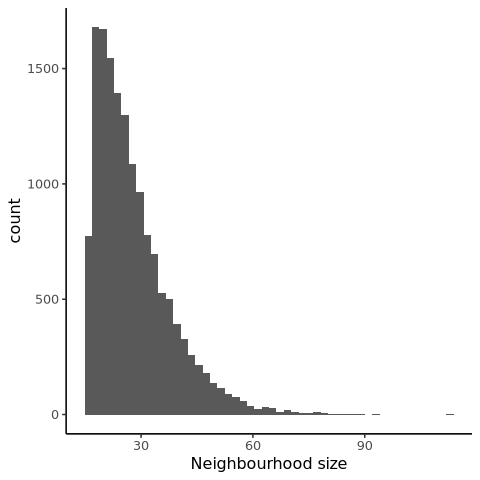

In [13]:
%%R -i knn_adjacency

milo_graph <- buildFromAdjacency(knn_adjacency, k=15, is.binary=TRUE)
graph(milo) <- miloR::graph(milo_graph)
milo <- buildGraph(milo, k=15, d=30)
milo <- makeNhoods(milo, prop=0.2, k=15, d=30, refined=TRUE, refinement_scheme='graph')
milo <- countCells(milo, meta.data=data.frame(colData(milo)), sample="wsi_id")

g <- plotNhoodSizeHist(milo)
save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/nhood_size_hist.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 5, height = 5)
g

In [14]:
%%R

milo

class: Milo 
dim: 512 97276 
metadata(17): cohort_colors leiden_0.5 ... source_colors umap
assays(1): X
rownames(512): 0 1 ... 510 511
rowData names(0):
colnames(97276): 0 1 ... 97274 97275
colData names(14): patient_id age ... leiden_2.0 risk
reducedDimNames(2): PCA UMAP
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 97276 14980
nhoodCounts dimensions(2): 14980 796
nhoodDistances dimension(1): 0
graph names(1): graph
nhoodIndex names(1): 14980
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1


In [58]:
mapping = {'N': 2, 'N_RRM': 1, 'N_RM': 0}
adata_normal.obs['risk'] = adata_normal.obs['source'].map(mapping)
knn_adjacency = adata_normal.obsp[f'nn_{n_neighbors}_connectivities']

# Mapping values from 'source' to 'risk'
design_df = adata_normal.obs[['patient_id', 'wsi_id', 'source', 'risk', 'age']]
design_df.index = design_df['wsi_id']
design_df.drop_duplicates(inplace=True)

# df_filtered = design_df.loc[pd.notna(design_df['age'])]
count_by_source = design_df.groupby('risk')['wsi_id'].nunique()
print(count_by_source)

design_df

risk
2    432
0    179
1    185
Name: wsi_id, dtype: int64


/tmp/ipykernel_518695/850127464.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  design_df.drop_duplicates(inplace=True)
/tmp/ipykernel_518695/850127464.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_source = design_df.groupby('risk')['wsi_id'].nunique()


,patient_id,wsi_id,source,risk,age
wsi_id,,,,,
BRACS_1003675_N_1,1003675,BRACS_1003675_N_1,N,2,NaN
BRACS_1003713_N_1,1003713,BRACS_1003713_N_1,N,2,NaN
BRACS_1003714_N_1,1003714,BRACS_1003714_N_1,N,2,NaN
BRACS_1003715_N_1,1003715,BRACS_1003715_N_1,N,2,NaN
BRACS_1003716_N_1,1003716,BRACS_1003716_N_1,N,2,NaN
...,...,...,...,...,...
BRACS_762_N_5,762,BRACS_762_N_5,N,2,NaN
BRACS_762_N_1,762,BRACS_762_N_1,N,2,NaN
BRACS_762_N_4,762,BRACS_762_N_4,N,2,NaN


In [56]:
%%R -i design_df -o design_df

zero_library_samples <- names(which(colSums(nhoodCounts(milo)) == 0))
nhoodCounts(milo) <- nhoodCounts(milo)[, !(colnames(nhoodCounts(milo)) %in% zero_library_samples)]
cat("Design matrix rows: ", nrow(design_df), "\n")
cat("Neighborhood count matrix columns: ", ncol(nhoodCounts(milo)), "\n")

design_df <- design_df[!(rownames(design_df) %in% zero_library_samples), ]
cat("Design matrix rows after filtering: ", nrow(design_df), "\n")
cat("Neighborhood count matrix columns after filtering: ", ncol(nhoodCounts(milo)), "\n")

Design matrix rows:  796 
Neighborhood count matrix columns:  796 
Design matrix rows after filtering:  796 
Neighborhood count matrix columns after filtering:  796 


/scratch/users/k21066795/conda/miloR/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "risk". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '


## DA testing berween N_RM, N_RRM, N, as ranked variable

In [15]:
%%R -i design_df -o DA_results

DA_results <- testNhoods(milo, design=~risk, design.df = design_df, fdr.weighting='graph-overlap')

Using TMM normalisation
Running with model contrasts
Performing spatial FDR correction with graph-overlap weighting
In addition: There were 50 or more warnings (use warnings() to see the first 50)


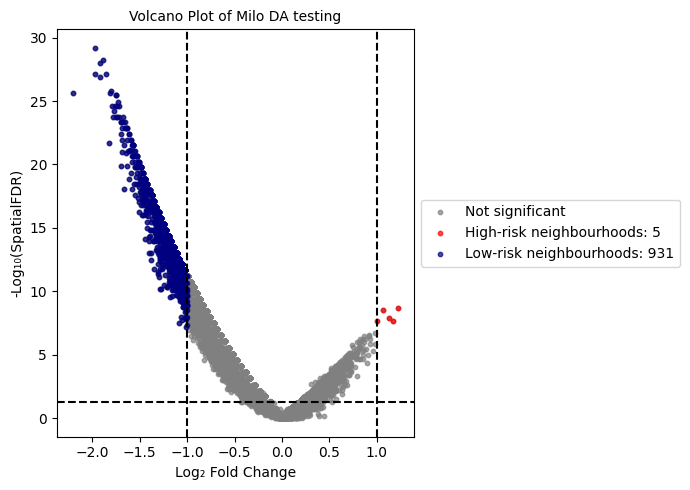

In [51]:
## Selection criteria
selected = (DA_results['SpatialFDR'] < 0.05) & (abs(DA_results['logFC']) >= 1)
selected_pos = selected & (DA_results['logFC'] >= 1)
selected_neg = selected & (DA_results['logFC'] <= -1)
count_pos = selected_pos.sum()
count_neg = selected_neg.sum()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    DA_results['logFC'], 
    -np.log10(DA_results['SpatialFDR']),
    c='grey', s=10, alpha=0.7, label='Not significant'
)
ax.scatter(
    DA_results.loc[selected_pos, 'logFC'],
    -np.log10(DA_results.loc[selected_pos, 'SpatialFDR']),
    c='red', alpha=0.7, s=10, label='High-risk neighbourhoods: 5'
)
ax.scatter(
    DA_results.loc[selected_neg, 'logFC'], 
    -np.log10(DA_results.loc[selected_neg, 'SpatialFDR']),
    c='navy', alpha=0.7, s=10, label='Low-risk neighbourhoods: 931'
)


ax.axhline(y=-np.log10(0.05), color='black', linestyle='--')
ax.axvline(x=1, color='black', linestyle='--')
ax.axvline(x=-1, color='black', linestyle='--')

ax.set_title('Volcano Plot of Milo DA testing', fontsize=10)
ax.set_xlabel('Log₂ Fold Change', fontsize=10)
ax.set_ylabel('-Log₁₀(SpatialFDR)', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig('/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/DAtest_volcanoplot.pdf')
plt.show()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


Adding nhood effect sizes to neighbourhood graph attributes


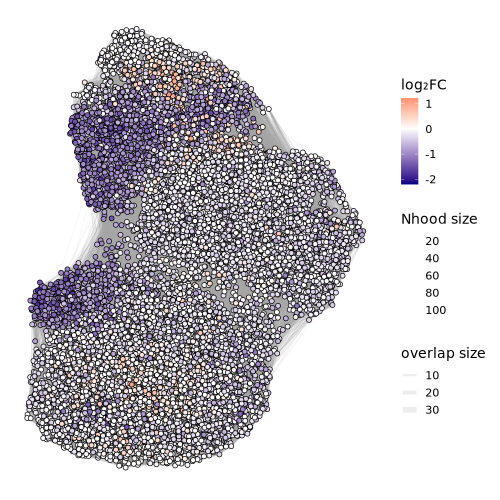

In [75]:
%%R -w 500 -h 500

milo <- buildNhoodGraph(milo)

g <- plotNhoodGraphDA(
  milo,
  DA_results,
  alpha       = 0.5,
  node_stroke = 0,
  layout      = 'UMAP',
  res_column  = 'logFC'
) +
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  )+
ggraph::geom_node_point(aes(fill = logFC), color = "black", shape = 21, size = 2) 


# save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012.pdf'
save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
g

In [73]:
DA_results = DA_results[DA_results['SpatialFDR'] < 0.05].copy()
DA_results

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
1,-0.899390,12.739131,265.969834,8.218316e-12,1.123977e-10,1.0,1.386582e-10
4,-0.936941,12.747642,179.565587,3.158754e-09,2.813977e-08,4.0,3.001157e-08
5,-0.254254,12.738997,63.862175,8.075376e-03,1.868685e-02,5.0,1.923262e-02
6,-0.474467,12.766271,71.906886,4.543301e-06,2.509802e-05,6.0,2.564312e-05
10,-0.372744,12.750992,66.329197,1.429392e-03,4.440903e-03,10.0,4.611257e-03
...,...,...,...,...,...,...,...
14957,-0.176160,12.736414,41.429656,8.119820e-03,1.868685e-02,14957.0,1.923262e-02
14961,0.429440,12.753783,54.978152,5.853383e-04,2.079192e-03,14961.0,2.162875e-03
14966,-0.310741,12.759422,35.580489,1.147976e-02,2.525482e-02,14966.0,2.604238e-02
14972,-0.254470,12.750992,52.680299,8.075376e-03,1.868685e-02,14972.0,1.923262e-02


Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


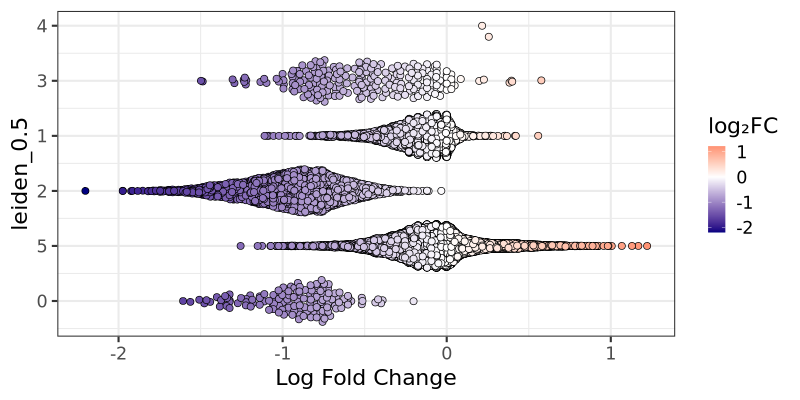

In [80]:
%%R -w 800 -h 400

groupby <- 'leiden_0.5'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")   


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_0.5.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 4)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_0.5.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 4)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


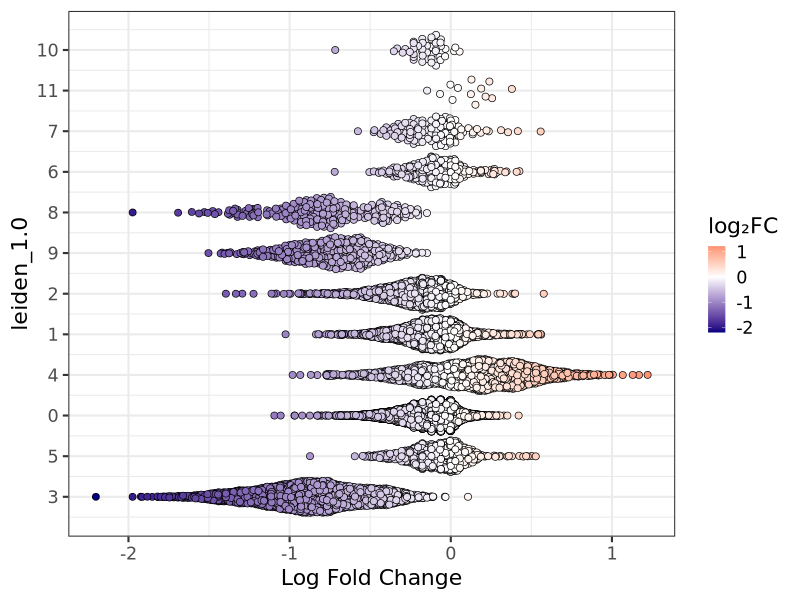

In [79]:
%%R -w 800 -h 600

groupby <- 'leiden_1.0'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2( 
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")  


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_1.0.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 6)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_1.0.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 6)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


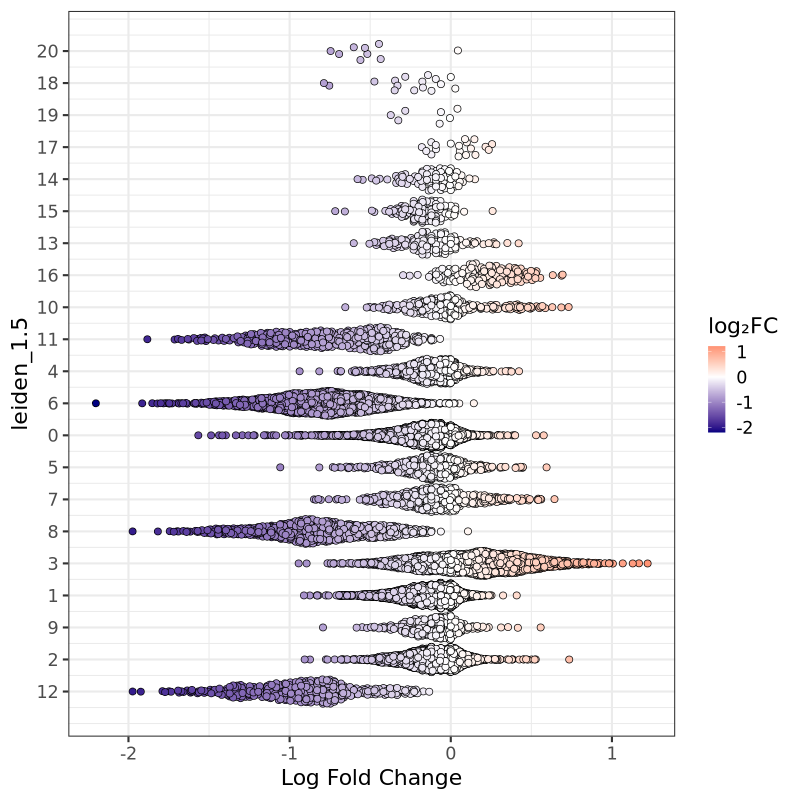

In [83]:
%%R -w 800 -h 800

groupby <- 'leiden_1.5'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),    
                      shape = 21, 
                      size = 3, 
                      color = "black")   


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_1.5.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_1.5.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


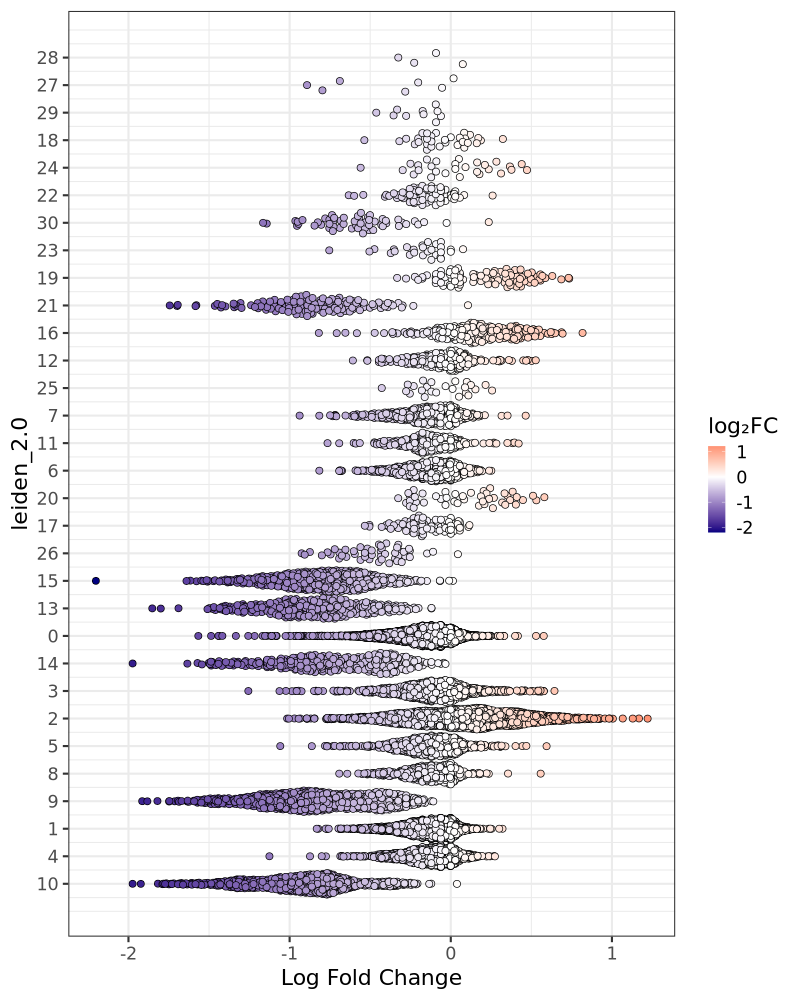

In [82]:
%%R -w 800 -h 1000

groupby <- 'leiden_2.0'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(   
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")  


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_2.0.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 10)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_risk012_annoByleiden_2.0.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 10)
g

## DA testing incoporating a contrast between N_RM vs N_RRM

In [100]:
%%R -i design_df -o DA_results

design_df$source <- factor(design_df$source, levels = c('N_RM', 'N_RRM', 'N'))

contrast.1 <- c("sourceN_RRM - sourceN_RM") # making sourceN_RM the reference and sourceN_RRM the comparison
DA_results <- testNhoods(milo, design = ~ 0 + source, design.df = design_df, model.contrasts = contrast.1, fdr.weighting = 'graph-overlap')

/scratch/users/k21066795/conda/miloR/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "risk". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '


Using TMM normalisation
Running with model contrasts
Performing spatial FDR correction with graph-overlap weighting
In addition: There were 50 or more warnings (use warnings() to see the first 50)


In [101]:
DA_results

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
1,0.178491,12.717247,8.118485,3.035810e-01,3.327462e-01,1.0,3.364448e-01
2,0.480712,12.723193,42.694705,8.602050e-03,1.239264e-02,2.0,1.305156e-02
3,-0.858874,12.719200,93.464975,6.646755e-08,4.080786e-07,3.0,5.607915e-07
4,0.680357,12.731342,117.380839,7.883076e-06,2.400622e-05,4.0,2.808603e-05
5,-1.261053,12.736689,201.102515,1.101087e-12,4.284278e-11,5.0,8.319478e-11
...,...,...,...,...,...,...,...
14976,-1.041832,12.726579,215.083012,5.837310e-10,7.745303e-09,14976.0,1.237921e-08
14977,0.601361,12.721405,93.320895,4.007868e-04,7.705071e-04,14977.0,8.447777e-04
14978,0.342831,12.718948,28.320702,5.087938e-02,6.359393e-02,14978.0,6.554105e-02
14979,0.803051,12.726488,124.125634,5.201872e-06,1.656549e-05,14979.0,1.964120e-05


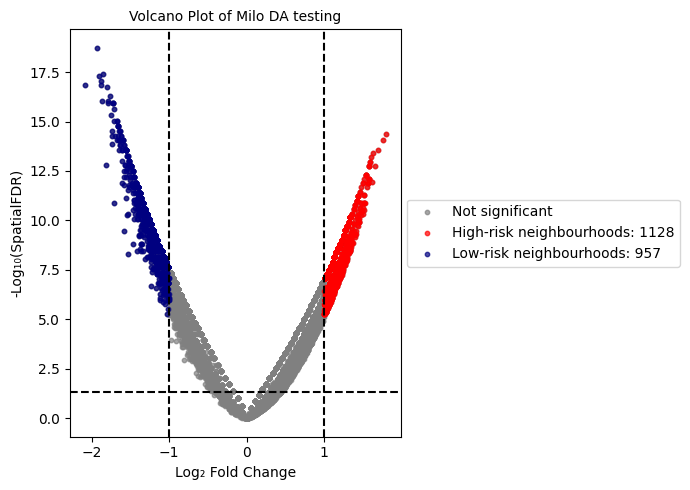

In [102]:
## Selection criteria
selected = (DA_results['SpatialFDR'] < 0.05) & (abs(DA_results['logFC']) >= 1)
selected_pos = selected & (DA_results['logFC'] >= 1)
selected_neg = selected & (DA_results['logFC'] <= -1)
count_pos = selected_pos.sum()
count_neg = selected_neg.sum()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    DA_results['logFC'], 
    -np.log10(DA_results['SpatialFDR']),
    c='grey', s=10, alpha=0.7, label='Not significant'
)
ax.scatter(
    DA_results.loc[selected_pos, 'logFC'],
    -np.log10(DA_results.loc[selected_pos, 'SpatialFDR']),
    c='red', alpha=0.7, s=10, label=f'High-risk neighbourhoods: {count_pos}'
)
ax.scatter(
    DA_results.loc[selected_neg, 'logFC'], 
    -np.log10(DA_results.loc[selected_neg, 'SpatialFDR']),
    c='navy', alpha=0.7, s=10, label=f'Low-risk neighbourhoods: {count_neg}'
)


ax.axhline(y=-np.log10(0.05), color='black', linestyle='--')
ax.axvline(x=1, color='black', linestyle='--')
ax.axvline(x=-1, color='black', linestyle='--')

ax.set_title('Volcano Plot of Milo DA testing', fontsize=10)
ax.set_xlabel('Log₂ Fold Change', fontsize=10)
ax.set_ylabel('-Log₁₀(SpatialFDR)', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig('/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/DAtest_volcanoplot_contrast_RM_RRM.pdf')
plt.show()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


Adding nhood effect sizes to neighbourhood graph attributes
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


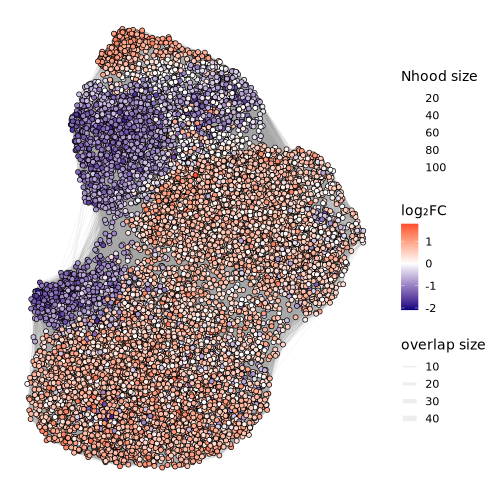

In [103]:
%%R -w 500 -h 500

library(ggplot2)

milo <- buildNhoodGraph(milo)

g <- plotNhoodGraphDA(
  milo,
  DA_results,
  alpha       = 0.5,
  node_stroke = 0,
  layout      = 'UMAP',
  res_column  = 'logFC'
) +
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  )+
ggraph::geom_node_point(aes(fill = logFC), color = "black", shape = 21, size = 2) 


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
g

In [104]:
DA_results = DA_results[DA_results['SpatialFDR'] < 0.05].copy()
DA_results

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
2,0.480712,12.723193,42.694705,8.602050e-03,1.239264e-02,2.0,1.305156e-02
3,-0.858874,12.719200,93.464975,6.646755e-08,4.080786e-07,3.0,5.607915e-07
4,0.680357,12.731342,117.380839,7.883076e-06,2.400622e-05,4.0,2.808603e-05
5,-1.261053,12.736689,201.102515,1.101087e-12,4.284278e-11,5.0,8.319478e-11
6,0.569704,12.719162,118.127892,5.632476e-05,1.362637e-04,6.0,1.549388e-04
...,...,...,...,...,...,...,...
14975,0.888935,12.724887,92.359085,8.439832e-07,3.507037e-06,14975.0,4.376520e-06
14976,-1.041832,12.726579,215.083012,5.837310e-10,7.745303e-09,14976.0,1.237921e-08
14977,0.601361,12.721405,93.320895,4.007868e-04,7.705071e-04,14977.0,8.447777e-04
14979,0.803051,12.726488,124.125634,5.201872e-06,1.656549e-05,14979.0,1.964120e-05


Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


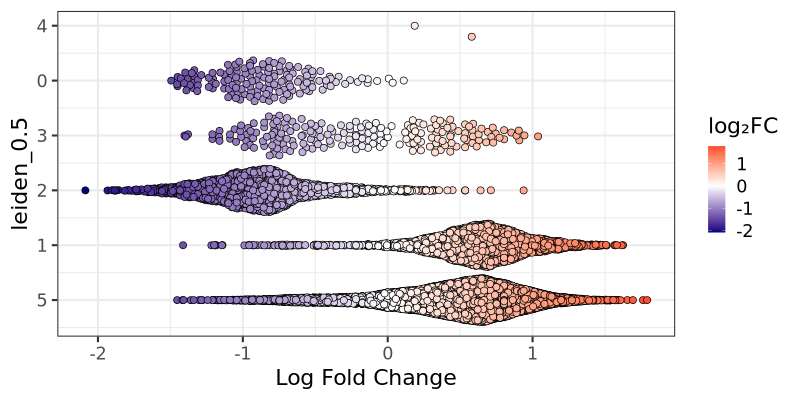

In [105]:
%%R -w 800 -h 400

groupby <- 'leiden_0.5'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")   


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_0.5.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 4)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_0.5.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 4)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


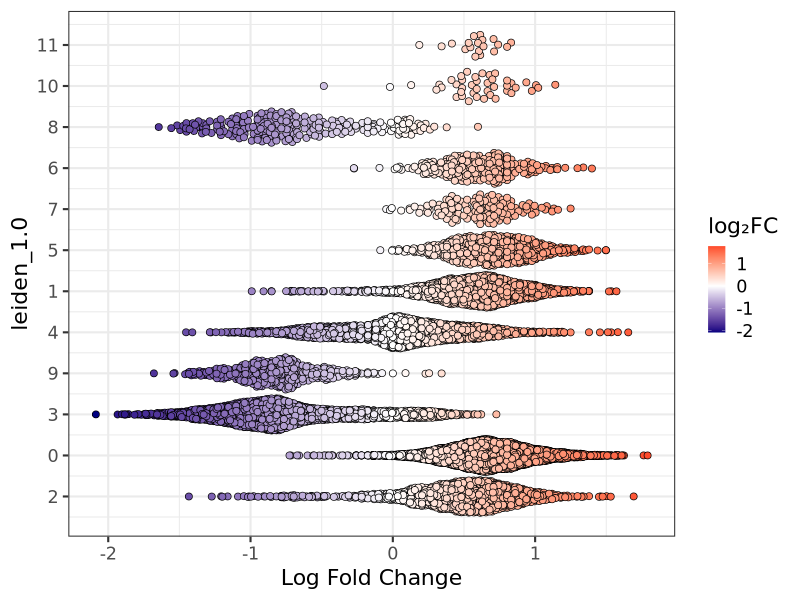

In [106]:
%%R -w 800 -h 600

groupby <- 'leiden_1.0'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2( 
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")  


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_1.0.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 6)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_1.0.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 6)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


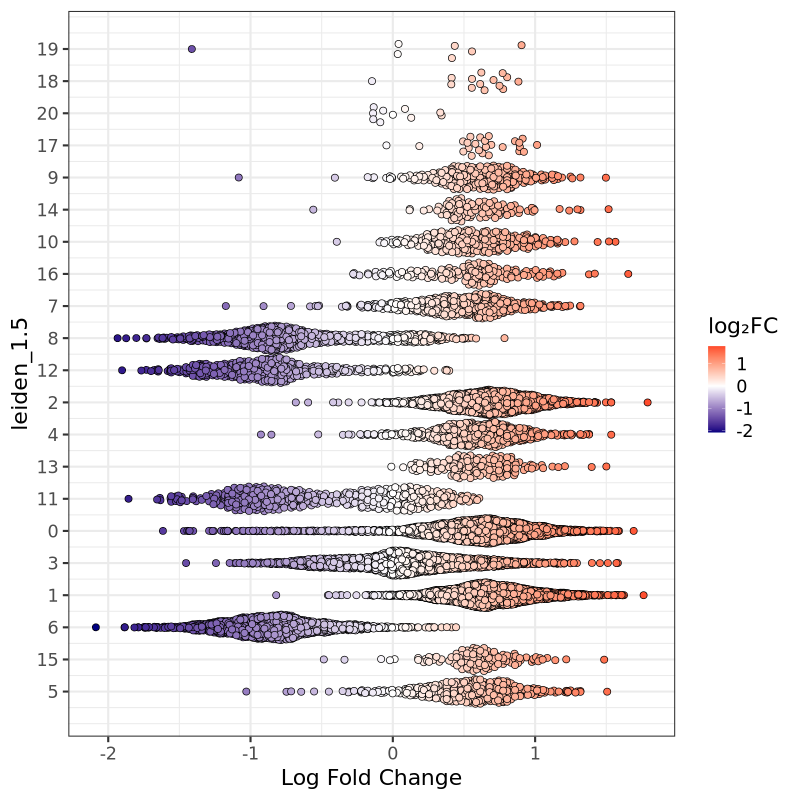

In [107]:
%%R -w 800 -h 800

groupby <- 'leiden_1.5'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),    
                      shape = 21, 
                      size = 3, 
                      color = "black")   


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_1.5.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_1.5.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


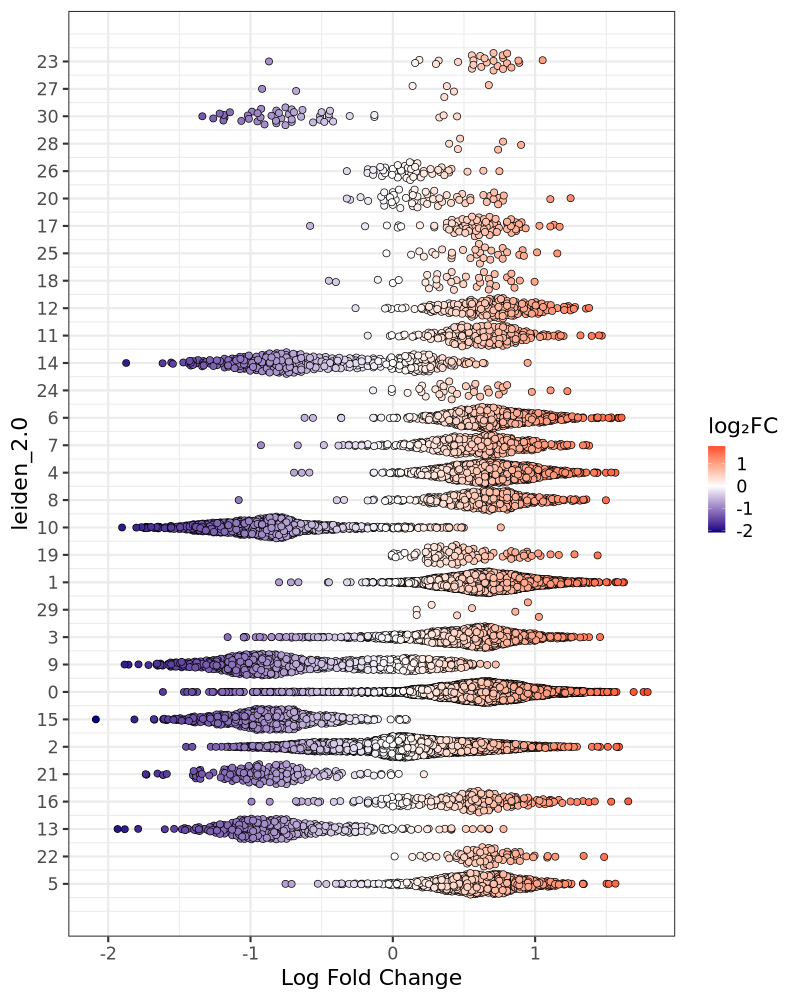

In [108]:
%%R -w 800 -h 1000

groupby <- 'leiden_2.0'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(   
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")  


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_2.0.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 10)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_RRM_annoByleiden_2.0.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 10)
g

## DA testing incoporating a contrast between N_RM vs N

In [109]:
%%R

design_df$source <- factor(design_df$source, levels = c("N_RM", "N_RRM", "N"))
contrast.2 <- c("sourceN - sourceN_RM")

DA_results <- testNhoods(milo, design = ~ 0 + source, design.df = design_df, model.contrasts = contrast.2, fdr.weighting = 'graph-overlap')

Using TMM normalisation
Running with model contrasts
Performing spatial FDR correction with graph-overlap weighting
In addition: There were 50 or more warnings (use warnings() to see the first 50)


In [110]:
DA_results

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
2,0.480712,12.723193,42.694705,8.602050e-03,1.239264e-02,2.0,1.305156e-02
3,-0.858874,12.719200,93.464975,6.646755e-08,4.080786e-07,3.0,5.607915e-07
4,0.680357,12.731342,117.380839,7.883076e-06,2.400622e-05,4.0,2.808603e-05
5,-1.261053,12.736689,201.102515,1.101087e-12,4.284278e-11,5.0,8.319478e-11
6,0.569704,12.719162,118.127892,5.632476e-05,1.362637e-04,6.0,1.549388e-04
...,...,...,...,...,...,...,...
14975,0.888935,12.724887,92.359085,8.439832e-07,3.507037e-06,14975.0,4.376520e-06
14976,-1.041832,12.726579,215.083012,5.837310e-10,7.745303e-09,14976.0,1.237921e-08
14977,0.601361,12.721405,93.320895,4.007868e-04,7.705071e-04,14977.0,8.447777e-04
14979,0.803051,12.726488,124.125634,5.201872e-06,1.656549e-05,14979.0,1.964120e-05


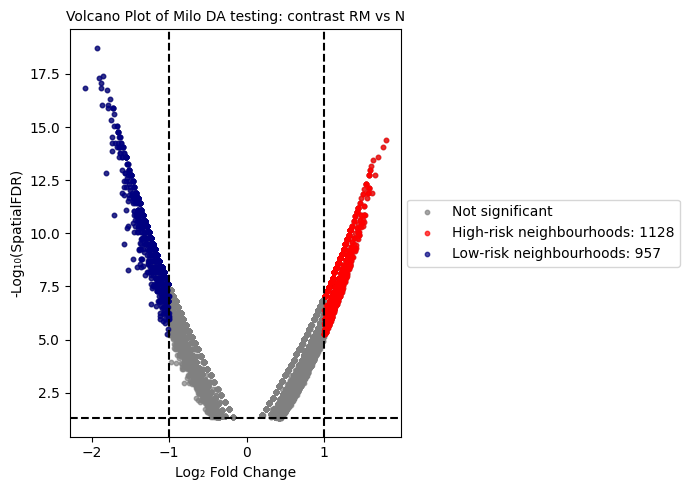

In [111]:
## Selection criteria
selected = (DA_results['SpatialFDR'] < 0.05) & (abs(DA_results['logFC']) >= 1)
selected_pos = selected & (DA_results['logFC'] >= 1)
selected_neg = selected & (DA_results['logFC'] <= -1)
count_pos = selected_pos.sum()
count_neg = selected_neg.sum()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    DA_results['logFC'], 
    -np.log10(DA_results['SpatialFDR']),
    c='grey', s=10, alpha=0.7, label='Not significant'
)
ax.scatter(
    DA_results.loc[selected_pos, 'logFC'],
    -np.log10(DA_results.loc[selected_pos, 'SpatialFDR']),
    c='red', alpha=0.7, s=10, label=f'High-risk neighbourhoods: {count_pos}'
)
ax.scatter(
    DA_results.loc[selected_neg, 'logFC'], 
    -np.log10(DA_results.loc[selected_neg, 'SpatialFDR']),
    c='navy', alpha=0.7, s=10, label=f'Low-risk neighbourhoods: {count_neg}'
)


ax.axhline(y=-np.log10(0.05), color='black', linestyle='--')
ax.axvline(x=1, color='black', linestyle='--')
ax.axvline(x=-1, color='black', linestyle='--')

ax.set_title('Volcano Plot of Milo DA testing: contrast RM vs N', fontsize=10)
ax.set_xlabel('Log₂ Fold Change', fontsize=10)
ax.set_ylabel('-Log₁₀(SpatialFDR)', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig('/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/DAtest_volcanoplot_contrast_RM_N.pdf')
plt.show()

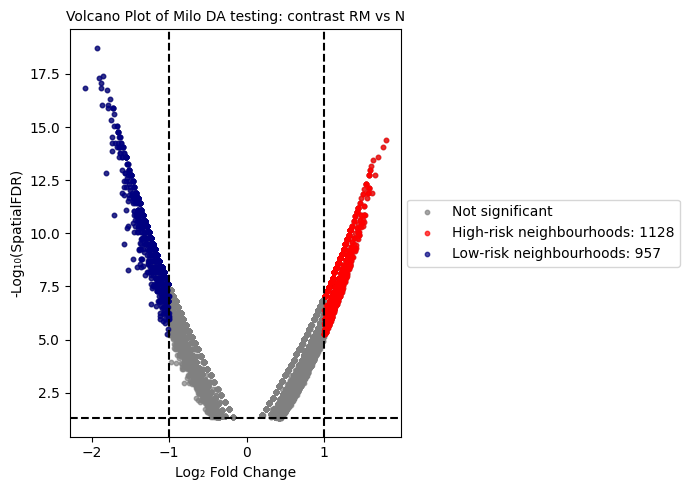

In [112]:
## Selection criteria
selected = (DA_results['SpatialFDR'] < 0.05) & (abs(DA_results['logFC']) >= 1)
selected_pos = selected & (DA_results['logFC'] >= 1)
selected_neg = selected & (DA_results['logFC'] <= -1)
count_pos = selected_pos.sum()
count_neg = selected_neg.sum()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    DA_results['logFC'], 
    -np.log10(DA_results['SpatialFDR']),
    c='grey', s=10, alpha=0.7, label='Not significant'
)
ax.scatter(
    DA_results.loc[selected_pos, 'logFC'],
    -np.log10(DA_results.loc[selected_pos, 'SpatialFDR']),
    c='red', alpha=0.7, s=10, label=f'High-risk neighbourhoods: {count_pos}'
)
ax.scatter(
    DA_results.loc[selected_neg, 'logFC'], 
    -np.log10(DA_results.loc[selected_neg, 'SpatialFDR']),
    c='navy', alpha=0.7, s=10, label=f'Low-risk neighbourhoods: {count_neg}'
)


ax.axhline(y=-np.log10(0.05), color='black', linestyle='--')
ax.axvline(x=1, color='black', linestyle='--')
ax.axvline(x=-1, color='black', linestyle='--')

ax.set_title('Volcano Plot of Milo DA testing: contrast RM vs N', fontsize=10)
ax.set_xlabel('Log₂ Fold Change', fontsize=10)
ax.set_ylabel('-Log₁₀(SpatialFDR)', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig('/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/DAtest_volcanoplot_contrast_RM_N.png')
plt.show()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


Adding nhood effect sizes to neighbourhood graph attributes
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


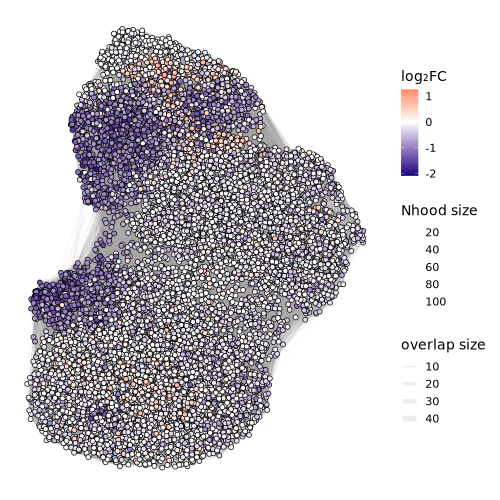

In [113]:
%%R -w 500 -h 500

milo <- buildNhoodGraph(milo)

g <- plotNhoodGraphDA(
  milo,
  DA_results,
  alpha       = 0.5,
  node_stroke = 0,
  layout      = 'UMAP',
  res_column  = 'logFC'
) +
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  )+
ggraph::geom_node_point(aes(fill = logFC), color = "black", shape = 21, size = 2) 


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
g

In [114]:
DA_results = DA_results[DA_results['SpatialFDR'] < 0.05].copy()
DA_results

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
2,0.480712,12.723193,42.694705,8.602050e-03,1.239264e-02,2.0,1.305156e-02
3,-0.858874,12.719200,93.464975,6.646755e-08,4.080786e-07,3.0,5.607915e-07
4,0.680357,12.731342,117.380839,7.883076e-06,2.400622e-05,4.0,2.808603e-05
5,-1.261053,12.736689,201.102515,1.101087e-12,4.284278e-11,5.0,8.319478e-11
6,0.569704,12.719162,118.127892,5.632476e-05,1.362637e-04,6.0,1.549388e-04
...,...,...,...,...,...,...,...
14975,0.888935,12.724887,92.359085,8.439832e-07,3.507037e-06,14975.0,4.376520e-06
14976,-1.041832,12.726579,215.083012,5.837310e-10,7.745303e-09,14976.0,1.237921e-08
14977,0.601361,12.721405,93.320895,4.007868e-04,7.705071e-04,14977.0,8.447777e-04
14979,0.803051,12.726488,124.125634,5.201872e-06,1.656549e-05,14979.0,1.964120e-05


Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


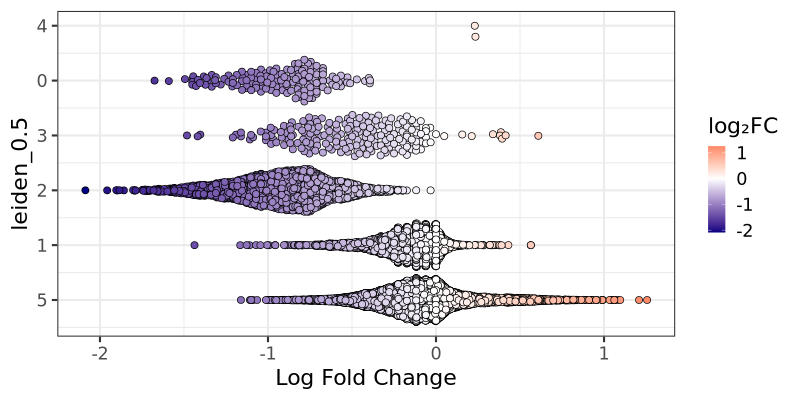

In [115]:
%%R -w 800 -h 400

groupby <- 'leiden_0.5'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")   


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_0.5.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 4)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_0.5.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 4)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


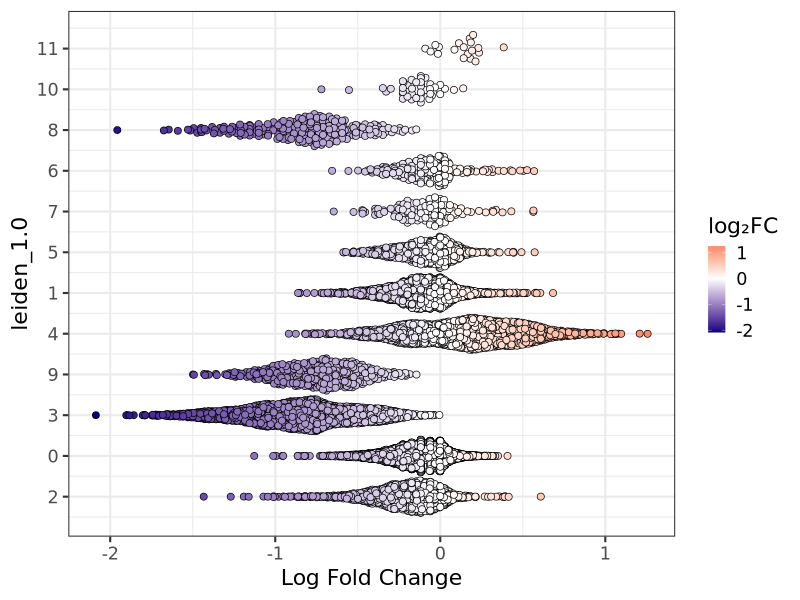

In [116]:
%%R -w 800 -h 600

groupby <- 'leiden_1.0'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2( 
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")  


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_1.0.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 6)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_1.0.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 6)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


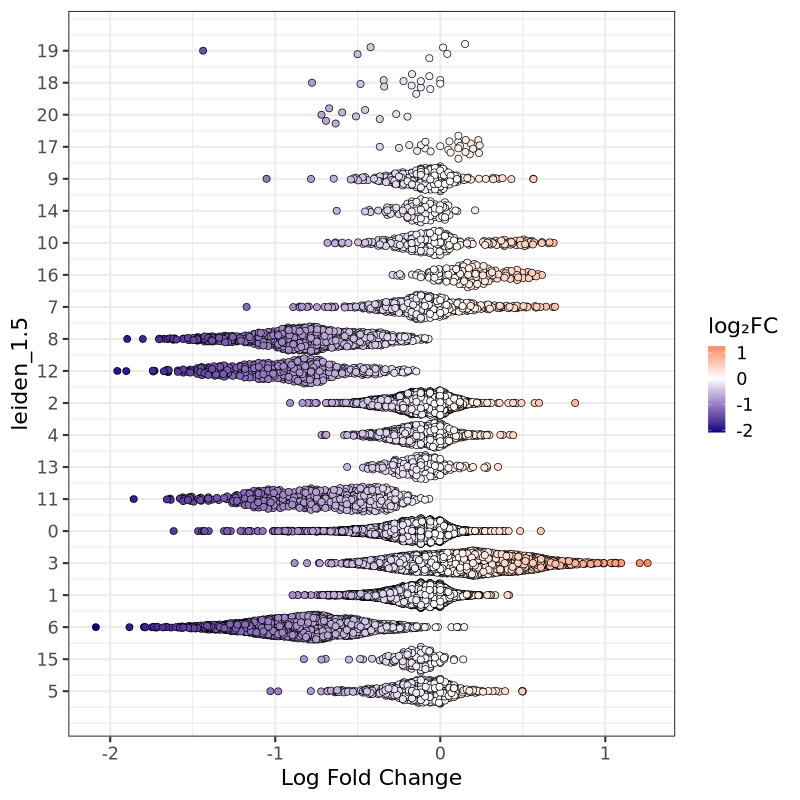

In [117]:
%%R -w 800 -h 800

groupby <- 'leiden_1.5'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(  
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),    
                      shape = 21, 
                      size = 3, 
                      color = "black")   


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_1.5.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_1.5.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 8)
g

Converting group_by to factor...
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'log₂FC' in 'mbcsToSbcs': for ₂ (U+2082)


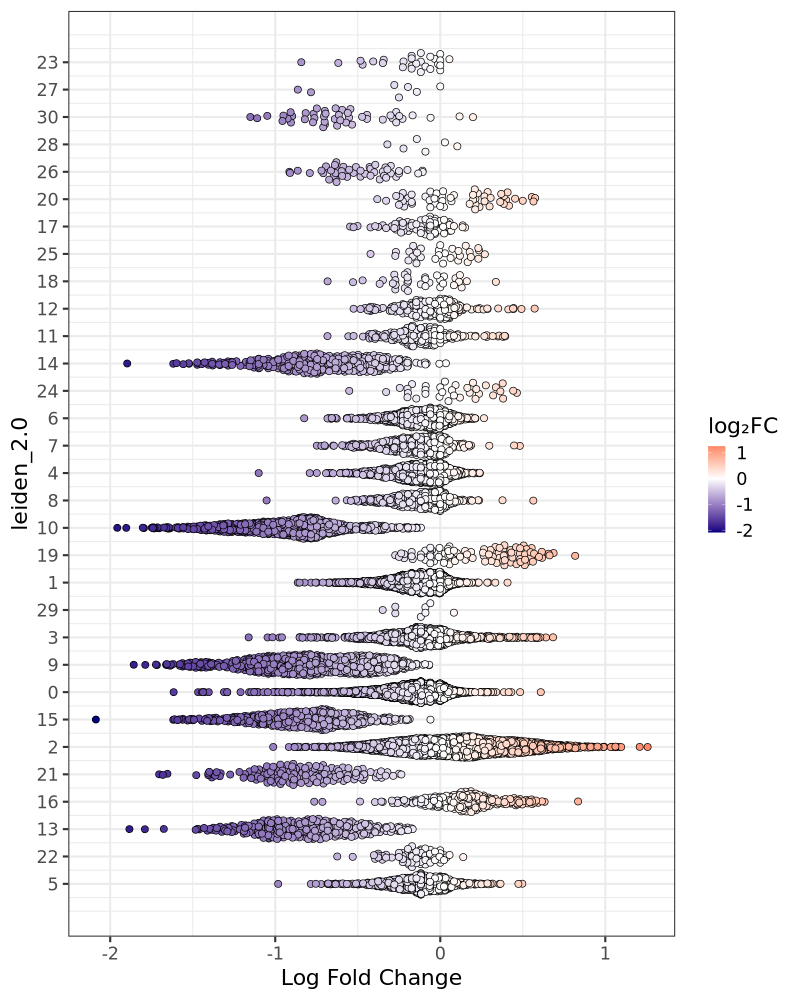

In [118]:
%%R -w 800 -h 1000

groupby <- 'leiden_2.0'
DA_results <- annotateNhoods(milo, DA_results, coldata_col = groupby)

g <- plotDAbeeswarm(DA_results, group.by = groupby)

g <- g + 
  scale_fill_gradient2(   
    low      = "navy",       # for negative logFC
    mid      = "white",
    high     = "red",        # for positive logFC
    midpoint = 0,
    name     = "log₂FC"
  ) + 
  ggplot2::geom_point(aes(fill = logFC),   
                      shape = 21, 
                      size = 3, 
                      color = "black")  


save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_2.0.pdf'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 10)

save_pt = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR/GraphDA_contrast_RM_N_annoByleiden_2.0.png'
ggplot2::ggsave(save_pt, plot = g, width = 8, height = 10)
g